<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseriesAnalysis_sarima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.3 MB/s eta 0:00:00


Fitting baseline SARIMA model...
Generating dynamic rolling predictions across test window...


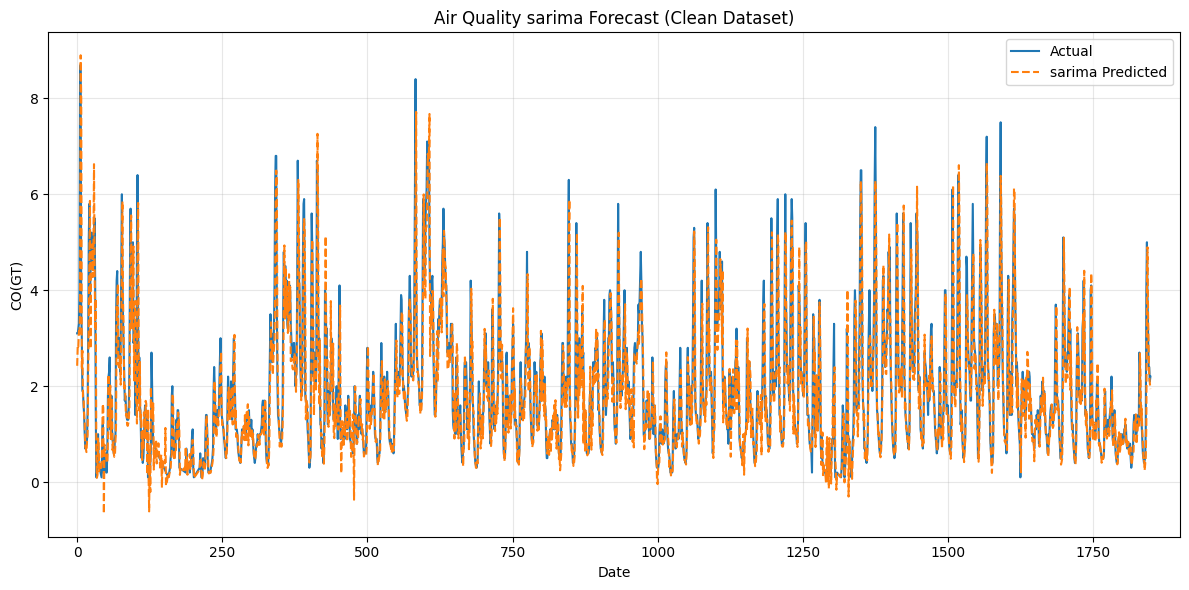

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------
# 1. DATA LOADING AND CLEANING
# ----------------------------------------------------
url = "/content/AirQualityUCI.csv"
df = pd.read_csv(url, sep=';', decimal=',')

df.dropna(how='all', inplace=True)
df = df.iloc[:, :15]

df.replace(-200, np.nan, inplace=True)
target = df['CO(GT)'].copy().interpolate(method='linear')
target = target.dropna().reset_index(drop=True)

# ----------------------------------------------------
# 2. TRAIN-TEST SPLIT
# ----------------------------------------------------
test_len = 1850
train = target.iloc[:-test_len]
test = target.iloc[-test_len:]

# ----------------------------------------------------
# 3. ROLLING / WALK-FORWARD FORECAST
# ----------------------------------------------------
# We fit on train, then use the 'extend' method to dynamically
# feed actual test observations forward without re-estimating parameters.
# This prevents the forecast from decaying to zero over 1850 steps.

print("Fitting baseline SARIMA model...")
# Standard AR(1) with daily seasonality (m=24)
base_model = SARIMAX(train,
                     order=(1, 0, 1),
                     seasonal_order=(1, 0, 0, 24),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
base_results = base_model.fit(disp=False)

print("Generating dynamic rolling predictions across test window...")
# Extend the model over the entire test history to capture rolling 24-hour cycles
extended_results = base_results.extend(test)
all_predictions = extended_results.fittedvalues

# Isolate only the predictions matching our test set window
predictions_test = all_predictions.iloc[-test_len:]

# ----------------------------------------------------
# 4. PLOTTING THE CORRECTED GRAPH
# ----------------------------------------------------
plt.figure(figsize=(12, 6))

# Reset indices to 0-1850 scale to match your exact visual format
x_axis = np.arange(test_len)

plt.plot(x_axis, test.values, label='Actual', color='#1f77b4', linewidth=1.5)
plt.plot(x_axis, predictions_test.values, label='sarima Predicted', color='#ff7f0e', linestyle='--', linewidth=1.5)

plt.title('Air Quality sarima Forecast (Clean Dataset)', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='-', alpha=0.3)
plt.xlim(-50, test_len + 50)

plt.tight_layout()
plt.savefig('air_quality_sarima_corrected.png', dpi=300)
plt.show()
